**The goal is to analyze global pollution data and develop strategies for pollution reduction and converting pollutants into energy**. The dataset will be
used for both data preprocessing and building regression models to predict energy recovery from pollution levels.


# **Phase 1: Data Collection and Exploratory Data Analysis (EDA)**

### **Step 1 - Data Import and Preprocessing**

In [1]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DATASETS/Global_Pollution_Analysis.csv")
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [6]:
df.shape

(200, 13)

In [7]:
df.columns

Index(['Country', 'Year', 'Air_Pollution_Index', 'Water_Pollution_Index',
       'Soil_Pollution_Index', 'Industrial_Waste (in tons)',
       'Energy_Recovered (in GWh)', 'CO2_Emissions (in MT)',
       'Renewable_Energy (%)', 'Plastic_Waste_Produced (in tons)',
       'Energy_Consumption_Per_Capita (in MWh)', 'Population (in millions)',
       'GDP_Per_Capita (in USD)'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    object 
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float6

**2. Handle Missing Values**

Identify missing or inconsistent data, and handle them using appropriate imputation strategies.


In [9]:
df.isnull().sum()

,0
Country,0
Year,0
Air_Pollution_Index,0
Water_Pollution_Index,0
Soil_Pollution_Index,0
Industrial_Waste (in tons),0
Energy_Recovered (in GWh),0
CO2_Emissions (in MT),0
Renewable_Energy (%),0
Plastic_Waste_Produced (in tons),0


`No missing or NULL values found`

**3. Data Transformation**

○ Normalize or scale pollution indices (air, water, and soil).

○ Encode categorical features such as Country and Year using label encoding or one-hot encoding.

Scaling the pollution indices via StandardScaler

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']] = scaler.fit_transform(df[['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']])


In [11]:
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,1.376167,0.193880,-0.619764,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,-1.403578,-1.153098,1.028744,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,-1.330788,-0.668076,1.142400,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,1.494394,-1.009403,0.431675,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,-0.021926,0.262567,1.138106,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


Encoding categorical features such as Country and Year using label encoding:

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Country'] = le.fit_transform(df['Country'])
df['Year'] = le.fit_transform(df['Year'])

In [13]:
df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,77,5,1.376167,0.193880,-0.619764,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,147,1,-1.403578,-1.153098,1.028744,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,136,16,-1.330788,-0.668076,1.142400,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,38,18,1.494394,-1.009403,0.431675,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,46,8,-0.021926,0.262567,1.138106,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


### **Step 2 - Exploratory Data Analysis (EDA)**

**1. Descriptive Statistics**

Calculate descriptive statistics for numerical features like CO2_Emissions and Industrial_Waste_in_tons.

In [14]:
df.describe()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
count,200.000000,200.000000,2.000000e+02,2.000000e+02,2.000000e+02,200.00000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000
mean,88.575000,9.335000,7.549517e-17,-3.552714e-16,2.486900e-16,52891.68150,260.448700,24.878100,27.799700,24492.893550,9.43575,104.271300,35307.602400
std,49.924107,5.765325,1.002509e+00,1.002509e+00,1.002509e+00,27224.49169,147.141923,14.470892,12.361879,14421.356002,5.57567,56.906574,19481.714455
min,0.000000,0.000000,-1.947928e+00,-1.768540e+00,-1.650240e+00,1019.37000,11.730000,1.920000,5.040000,542.950000,0.53000,2.320000,1298.700000
25%,45.750000,4.000000,-6.823730e-01,-8.536990e-01,-8.989775e-01,31201.97250,118.355000,11.220000,17.700000,12843.882500,4.58250,60.960000,19525.020000
50%,90.500000,10.000000,4.122312e-02,-5.821733e-02,5.332837e-02,55299.15000,273.140000,25.355000,29.170000,24121.540000,9.22500,104.965000,35043.325000
75%,131.000000,14.000000,8.489305e-01,8.935479e-01,8.265007e-01,74805.82500,384.957500,38.550000,37.072500,36516.232500,13.99750,150.930000,51629.547500
max,174.000000,19.000000,1.753566e+00,1.775151e+00,1.837213e+00,99739.36000,499.980000,49.690000,49.560000,49852.280000,19.98000,198.820000,69143.140000


### Descriptive Statistics

Descriptive statistics were generated using `df.describe()` to understand the distribution of numerical variables.

Observations:
- Average Energy Recovered is approximately `260.45 GWh.`
- Average CO2 Emissions are approximately `24.88 MT.`
- Renewable Energy contributes about `27.8% on average.`
- Industrial Waste shows a large range, indicating significant variation across countries.

**2. Correlation Analysis**

Visualize the correlation between pollution levels and other features like energy consumption using a heatmap

+1  → Perfect Positive Correlation

 0  → No Correlation

-1  → Perfect Negative Correlation

In [15]:
df.corr(numeric_only=True)

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
Country,1.000000,-0.097796,0.116879,0.023871,-0.043618,0.011995,-0.044316,0.006350,0.017480,0.112104,0.052141,-0.037139,-0.026500
Year,-0.097796,1.000000,0.008147,0.007790,0.052949,-0.064372,0.088332,0.002163,0.079472,-0.108469,-0.073536,0.144039,-0.141585
Air_Pollution_Index,0.116879,0.008147,1.000000,-0.022540,0.036020,0.033252,0.002997,-0.038179,0.011301,-0.018517,-0.053284,-0.028884,-0.069371
Water_Pollution_Index,0.023871,0.007790,-0.022540,1.000000,-0.020505,0.126092,-0.041828,-0.002979,-0.056183,0.044215,-0.001960,0.239446,-0.019975
Soil_Pollution_Index,-0.043618,0.052949,0.036020,-0.020505,1.000000,0.026609,0.064076,0.041913,-0.077602,0.129932,-0.023043,-0.100273,0.115521
Industrial_Waste (in tons),0.011995,-0.064372,0.033252,0.126092,0.026609,1.000000,-0.161309,-0.060737,-0.149251,0.066844,0.017323,-0.030398,0.061563
Energy_Recovered (in GWh),-0.044316,0.088332,0.002997,-0.041828,0.064076,-0.161309,1.000000,0.024758,0.043533,-0.072946,-0.030284,-0.075100,0.004535
CO2_Emissions (in MT),0.006350,0.002163,-0.038179,-0.002979,0.041913,-0.060737,0.024758,1.000000,-0.038888,0.065154,-0.011750,0.020784,0.029267
Renewable_Energy (%),0.017480,0.079472,0.011301,-0.056183,-0.077602,-0.149251,0.043533,-0.038888,1.000000,-0.125175,0.040398,-0.008378,-0.221096
Plastic_Waste_Produced (in tons),0.112104,-0.108469,-0.018517,0.044215,0.129932,0.066844,-0.072946,0.065154,-0.125175,1.000000,-0.021884,-0.029782,0.090283


Looking down the `Energy_Recovered` column:

**The highest correlation with Energy_Recovered:**


- Year                  -  ` 0.088`

- Soil_Pollution_Index  -   `0.064`

- Renewable_Energy      -   `0.044`

- CO2_Emissions         -   `0.025`

- GDP_Per_Capita        -   `0.005`


Creating heatmap:

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

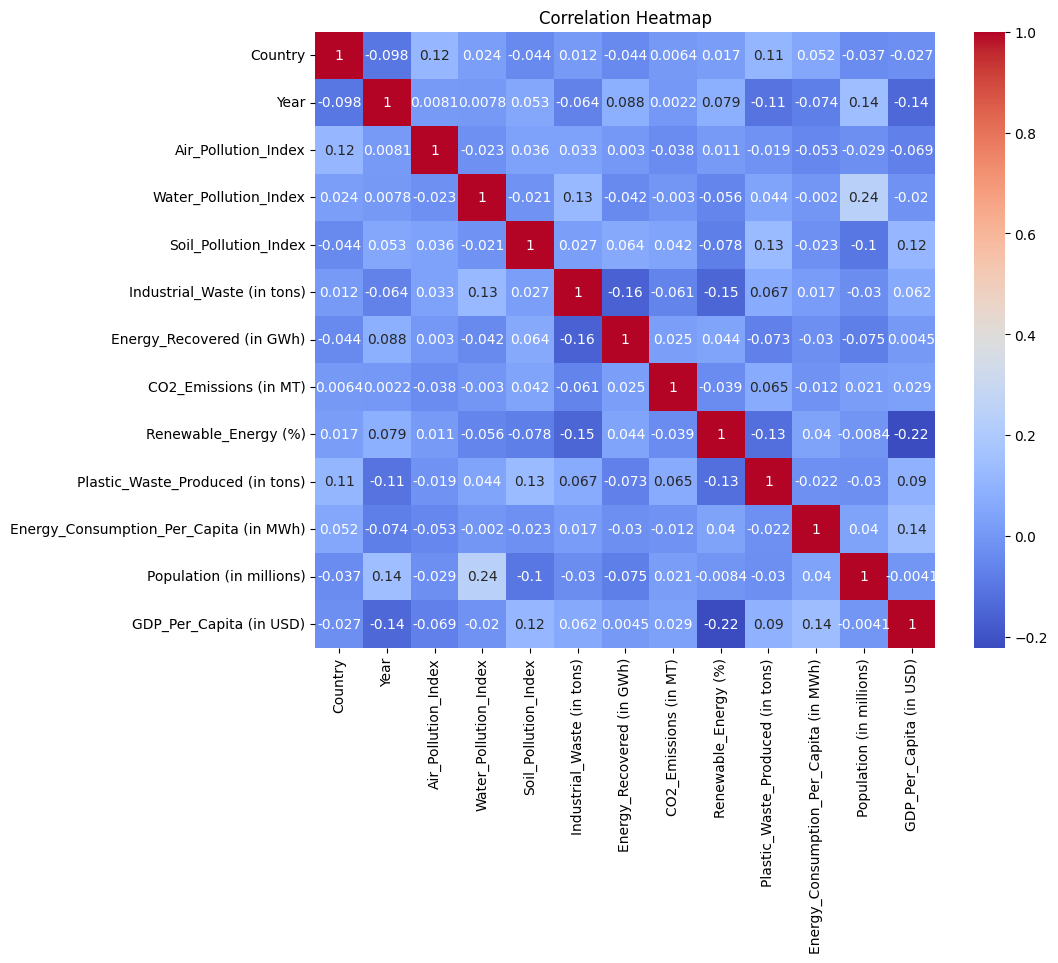

In [17]:
plt.figure(figsize=(10, 8))

plt.title("Correlation Heatmap")

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap = "coolwarm")

plt.show()

### Correlation Analysis

A correlation heatmap was generated to examine relationships between numerical features.

Observations:
- Most features show weak correlations with each other.
- Water_Pollution_Index and Population have the highest positive correlation (≈ 0.24).
- Renewable_Energy and GDP_Per_Capita show the strongest negative correlation (≈ -0.22).
- Energy_Recovered has only weak correlations with other variables, indicating that predicting energy recovery may be challenging using simple linear relationships.

**3. Visualizations**

Create bar charts, line plots, and box plots to explore trends in pollution over time and across countries.


***Since we Encoded Country and Year Data , we will use different dataframe just for visualization***

In [21]:
df_viz = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/DATASETS/Global_Pollution_Analysis.csv")
df_viz[["Country","Year"]].head()

,Country,Year
0,Hungary,2005
1,Singapore,2001
2,Romania,2016
3,Cook Islands,2018
4,Djibouti,2008


In [25]:
df_viz.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    object 
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    float6

In [22]:
yearly_air = df_viz.groupby("Year")["Air_Pollution_Index"].mean()

yearly_air.head()

,Air_Pollution_Index
Year,
2000,197.796000
2001,137.964444
2002,174.661538
2003,203.103000
2004,171.120909


`GROUPED THE YEAR AND AIR_PO. SO THAT IT GIVES AVERAGE PER YEAR ,AND PLOTS YEAR WISE, SO REPEATING YEARS DOESNT GET COUNTED INSTEAD IT GIVES AVG AIR_PO.`

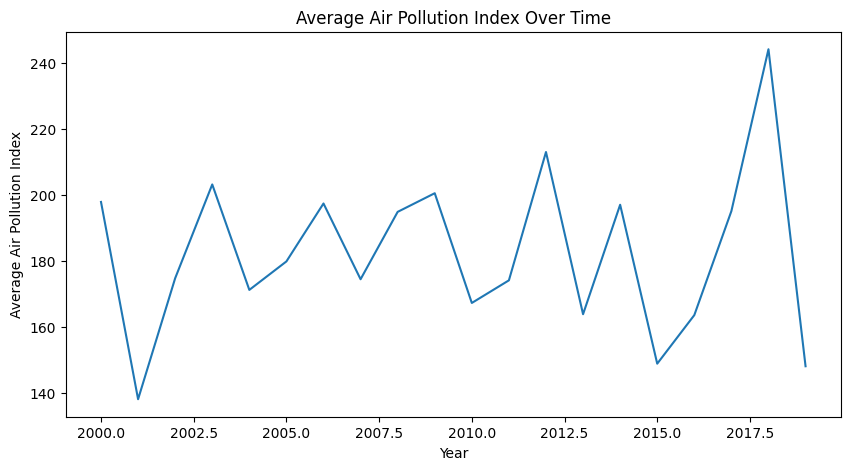

In [27]:
plt.figure(figsize=(10,5))

plt.plot(yearly_air.index, yearly_air.values)

plt.title("Average Air Pollution Index Over Time")
plt.xlabel("Year")
plt.ylabel("Average Air Pollution Index")

plt.show()


The average Air Pollution Index does not show a consistent increasing or decreasing trend over the years. Instead, pollution levels fluctuate, indicating varying environmental conditions and pollution control measures across different periods.

In [28]:
yearly_pollution = df_viz.groupby("Year")[[
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index"
]].mean()

yearly_pollution.head()

,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index
Year,,,
2000,197.796000,118.513000,69.283000
2001,137.964444,83.933333,71.340000
2002,174.661538,123.617692,75.344615
2003,203.103000,133.080000,100.687000
2004,171.120909,120.719091,69.959091


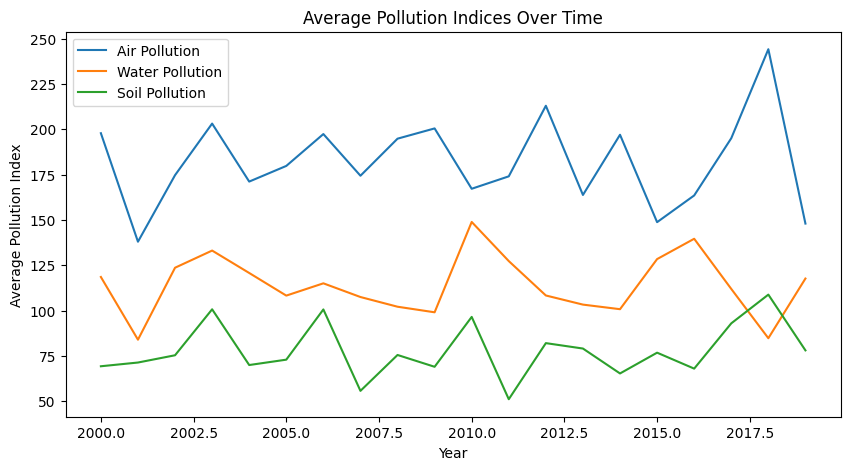

In [31]:
plt.figure(figsize=(10,5))

plt.plot(
    yearly_pollution.index,
    yearly_pollution["Air_Pollution_Index"],
    label="Air Pollution"
)

plt.plot(
    yearly_pollution.index,
    yearly_pollution["Water_Pollution_Index"],
    label="Water Pollution"
)

plt.plot(
    yearly_pollution.index,
    yearly_pollution["Soil_Pollution_Index"],
    label="Soil Pollution"
)

plt.title("Average Pollution Indices Over Time")
plt.xlabel("Year")
plt.ylabel("Average Pollution Index")

plt.legend()

plt.show()

### Line Plot Analysis

Observations:
- Air Pollution Index remains consistently higher than Water and Soil Pollution Indices throughout most years.
- Water Pollution Index shows moderate fluctuations over time.
- Soil Pollution Index generally remains the lowest among the three pollution measures.
- `Pollution levels vary across years and do not exhibit a consistent increasing or decreasing trend.`

BAR CHART :

In [32]:
df_viz["Country"].nunique()

175

In [42]:
df_viz["Pollution_Score"] = (
    df_viz["Air_Pollution_Index"] +
    df_viz["Water_Pollution_Index"] +
    df_viz["Soil_Pollution_Index"]
) / 3

In [41]:
top10_pollution = (
    df_viz.groupby("Country")["Pollution_Score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

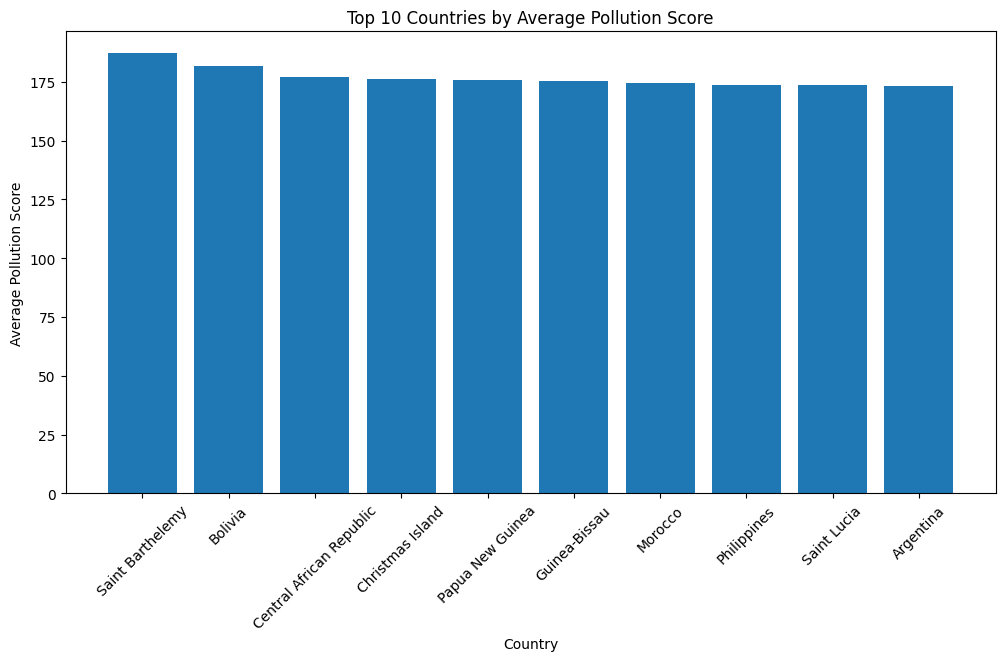

In [43]:
plt.figure(figsize=(12,6))

plt.bar(top10_pollution.index, top10_pollution.values)

plt.title("Top 10 Countries by Average Pollution Score")
plt.xlabel("Country")
plt.ylabel("Average Pollution Score")

plt.xticks(rotation=45)

plt.show()

### Bar Chart Analysis

A bar chart was created to compare the top 10 countries based on their average pollution score. The pollution score was calculated as the average of Air, Water, and Soil Pollution Indices.

Observations:
- Saint Barthelemy recorded the highest average pollution score.
- The top 10 countries have relatively similar pollution levels.
- No country showed an extremely higher pollution score compared to the others in the top 10.

**BOX PLOT:**

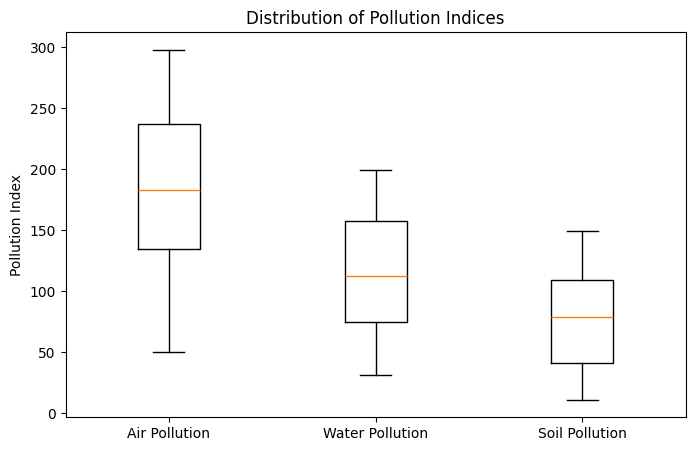

In [44]:
plt.figure(figsize=(8,5))

plt.boxplot([
    df_viz["Air_Pollution_Index"],
    df_viz["Water_Pollution_Index"],
    df_viz["Soil_Pollution_Index"]
])

plt.xticks(
    [1,2,3],
    ["Air Pollution","Water Pollution","Soil Pollution"]
)

plt.title("Distribution of Pollution Indices")
plt.ylabel("Pollution Index")

plt.show()

What does plt.xticks() do?

It changes the labels shown on the x-axis.

Syntax:

`plt.xticks(
    positions,
    labels )`

[1,2,3]

These are the positions of the boxplots.

Boxplot 1 → Position 1

Boxplot 2 → Position 2

Boxplot 3 → Position 3

### Box Plot Analysis

Box plots were created for Air, Water, and Soil Pollution Indices to examine their distributions and identify potential outliers.

Observations:
- Air Pollution has the highest median pollution level.
- Water Pollution shows moderate pollution levels.
- Soil Pollution has the lowest median value.
- Air Pollution exhibits the largest spread, indicating greater variability.
- No significant outliers were observed in the pollution indices.

### **Step 3 - Feature Engineering**

1. Yearly Trends

Extract year-based trends to understand how pollution and energy recovery have evolved over time.

In [45]:
yearly_trends = df_viz.groupby("Year")[[
    "Air_Pollution_Index",
    "Water_Pollution_Index",
    "Soil_Pollution_Index",
    "Energy_Recovered (in GWh)"
]].mean()

yearly_trends.head()

,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Energy_Recovered (in GWh)
Year,,,,
2000,197.796000,118.513000,69.283000,296.889000
2001,137.964444,83.933333,71.340000,288.877778
2002,174.661538,123.617692,75.344615,259.750769
2003,203.103000,133.080000,100.687000,208.139000
2004,171.120909,120.719091,69.959091,186.458182


2. Energy Consumption per Capita

Calculate energy consumption per capita for better analysis

### Energy Consumption per Capita

The dataset already contains the feature
`Energy_Consumption_Per_Capita (in MWh)`.
Therefore, no additional calculation was required.
The existing feature was retained for further analysis and modeling.

In [48]:
yearly_energyPcap = df_viz.groupby("Year")["Energy_Consumption_Per_Capita (in MWh)"].mean()

yearly_energyPcap.head()

,Energy_Consumption_Per_Capita (in MWh)
Year,
2000,11.969000
2001,9.268889
2002,9.295385
2003,12.074000
2004,8.210000


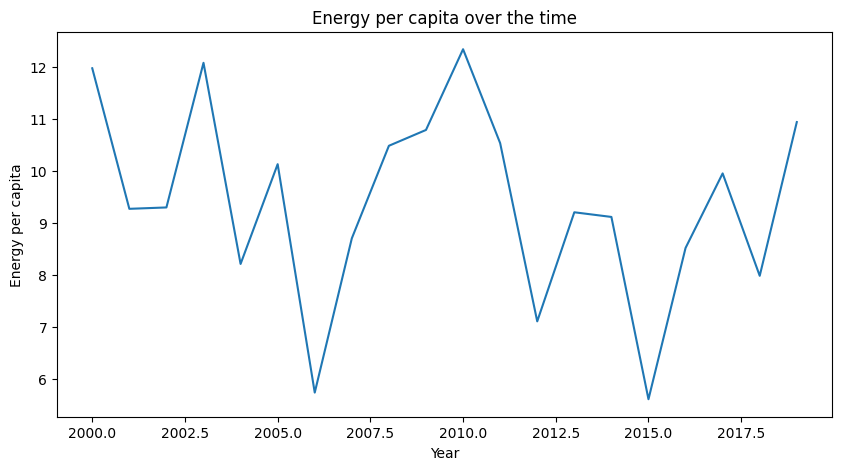

In [49]:
plt.figure(figsize=(10,5))

plt.plot(yearly_energyPcap.index, yearly_energyPcap.values)

plt.title("Energy per capita over the time")
plt.xlabel("Year")
plt.ylabel("Energy per capita")

plt.show()


### Energy Consumption Per Capita Analysis

A line plot was created to analyze the trend of average energy consumption per capita over time.

Observations:
- Energy consumption per capita fluctuates across years rather than showing a steady upward or downward trend.
- The highest average consumption was observed around 2010.
- The lowest average consumption was observed around 2015.
- The variation suggests changes in energy demand, efficiency, or consumption patterns over different years.

# **Phase 2: Predictive Modeling**

### **Step 4 - Linear Regression Model (for Pollution Prediction)**

1. Model Objective

Predict energy recovery (in GWh) based on pollution levels, industrial waste, and other features.


2. Model Building

Train a Linear Regression model to predict energy recovery using features like `Air_Pollution_Index, CO2_Emissions, and Industrial_Waste_in_tons.`



- Selecting features

In [96]:
x = df[[
    "Air_Pollution_Index",
    "Soil_Pollution_Index",
    "Industrial_Waste (in tons)",
    "CO2_Emissions (in MT)",
]]

y = df["Energy_Recovered (in GWh)"]

- Train-Test Split

In [97]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 4)
(40, 4)
(160,)
(40,)


- Applying LinearRegression

In [98]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train, y_train)

LinearRegression()

In [99]:
y_pred = model.predict(x_test)

In [100]:
print("Actual Values:")
print(y_test.head())

print("\nPredicted Values:")
print(y_pred[:5])

Actual Values:
95     307.89
15     367.65
30     109.13
158     93.73
128     54.32
Name: Energy_Recovered (in GWh), dtype: float64

Predicted Values:
[235.67962126 259.34255489 298.60616686 255.81603444 250.17383302]


**3. Evaluation Metrics**

Use R², Mean Squared Error (MSE), and Mean Absolute Error (MAE) to evaluate model performance.

In [101]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R² Score:", r2)
print("MSE:", mse)
print("MAE:", mae)

R² Score: -0.014782377689231518
MSE: 24539.70752682162
MAE: 141.35283321194905


`R² Score`


How much of the variation in Energy Recovery
is explained by the model.


`MAE (Mean Absolute Error)`


On average, how far are predictions from actual values?

`MSE (Mean Squared Error)`

Same idea as MAE, but large errors get punished more heavily.

A few terrible predictions will increase MSE a lot.

A Linear Regression model was tested using only Air Pollution Index, Soil Pollution Index, Industrial Waste, and CO₂ Emissions.

Results:

- R² Score : -0.015
- MSE : 24540
- MAE : 141.35

Observations:
- The model performed poorly, as indicated by the negative R² score.
- Predictions deviated significantly from actual values.
- Correlation analysis also revealed weak relationships between Energy Recovered and most predictor variables, which may explain the low predictive performance.

### **Step 5 - Logistic Regression Model (for Categorization of Pollution Levels)**

1. Model Objective

Classify countries into pollution severity categories (Low, Medium, High).

For this we have to create the target column

| Pollution Score | Category |
| --------------- | -------- |
| Lowest 33%      | Low      |
| Middle 33%      | Medium   |
| Highest 33%     | High     |


Creating Pollution_Score Column using the 3 pollution indices

In [103]:
df["Pollution_Score"] = (
    df["Air_Pollution_Index"] +
    df["Water_Pollution_Index"] +
    df["Soil_Pollution_Index"]
) / 3

Now We create the target column :

In [106]:
df["Pollution_Level"] = pd.qcut(
    df["Pollution_Score"],
    q=3,
    labels=["Low", "Medium", "High"]
) #q=3 means: Split the dataset into 3 equally-sized groups.

In [107]:
df[["Pollution_Score", "Pollution_Level"]].head()

,Pollution_Score,Pollution_Level
0,0.316761,High
1,-0.509310,Low
2,-0.285488,Low
3,0.305555,High
4,0.459582,High


In [108]:
df["Pollution_Level"].value_counts()

,count
Pollution_Level,
Low,67
High,67
Medium,66


We have to encode this target column :

In [109]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Pollution_Level"] = le.fit_transform(df["Pollution_Level"])

In [111]:
df["Pollution_Level"].head()

,Pollution_Level
0,0
1,1
2,1
3,0
4,0


In [115]:
df.corr(numeric_only=True)

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD),Pollution_Score,Pollution_Level
Country,1.000000,-0.097796,0.116879,0.023871,-0.043618,0.011995,-0.044316,0.006350,0.017480,0.112104,0.052141,-0.037139,-0.026500,0.056211,0.038855
Year,-0.097796,1.000000,0.008147,0.007790,0.052949,-0.064372,0.088332,0.002163,0.079472,-0.108469,-0.073536,0.144039,-0.141585,0.039865,-0.059349
Air_Pollution_Index,0.116879,0.008147,1.000000,-0.022540,0.036020,0.033252,0.002997,-0.038179,0.011301,-0.018517,-0.053284,-0.028884,-0.069371,0.586508,-0.333202
Water_Pollution_Index,0.023871,0.007790,-0.022540,1.000000,-0.020505,0.126092,-0.041828,-0.002979,-0.056183,0.044215,-0.001960,0.239446,-0.019975,0.553797,-0.184786
Soil_Pollution_Index,-0.043618,0.052949,0.036020,-0.020505,1.000000,0.026609,0.064076,0.041913,-0.077602,0.129932,-0.023043,-0.100273,0.115521,0.587686,-0.201248
Industrial_Waste (in tons),0.011995,-0.064372,0.033252,0.126092,0.026609,1.000000,-0.161309,-0.060737,-0.149251,0.066844,0.017323,-0.030398,0.061563,0.107612,-0.081523
Energy_Recovered (in GWh),-0.044316,0.088332,0.002997,-0.041828,0.064076,-0.161309,1.000000,0.024758,0.043533,-0.072946,-0.030284,-0.075100,0.004535,0.014609,0.037473
CO2_Emissions (in MT),0.006350,0.002163,-0.038179,-0.002979,0.041913,-0.060737,0.024758,1.000000,-0.038888,0.065154,-0.011750,0.020784,0.029267,0.000437,-0.164763
Renewable_Energy (%),0.017480,0.079472,0.011301,-0.056183,-0.077602,-0.149251,0.043533,-0.038888,1.000000,-0.125175,0.040398,-0.008378,-0.221096,-0.070883,0.055209
Plastic_Waste_Produced (in tons),0.112104,-0.108469,-0.018517,0.044215,0.129932,0.066844,-0.072946,0.065154,-0.125175,1.000000,-0.021884,-0.029782,0.090283,0.090064,-0.053062


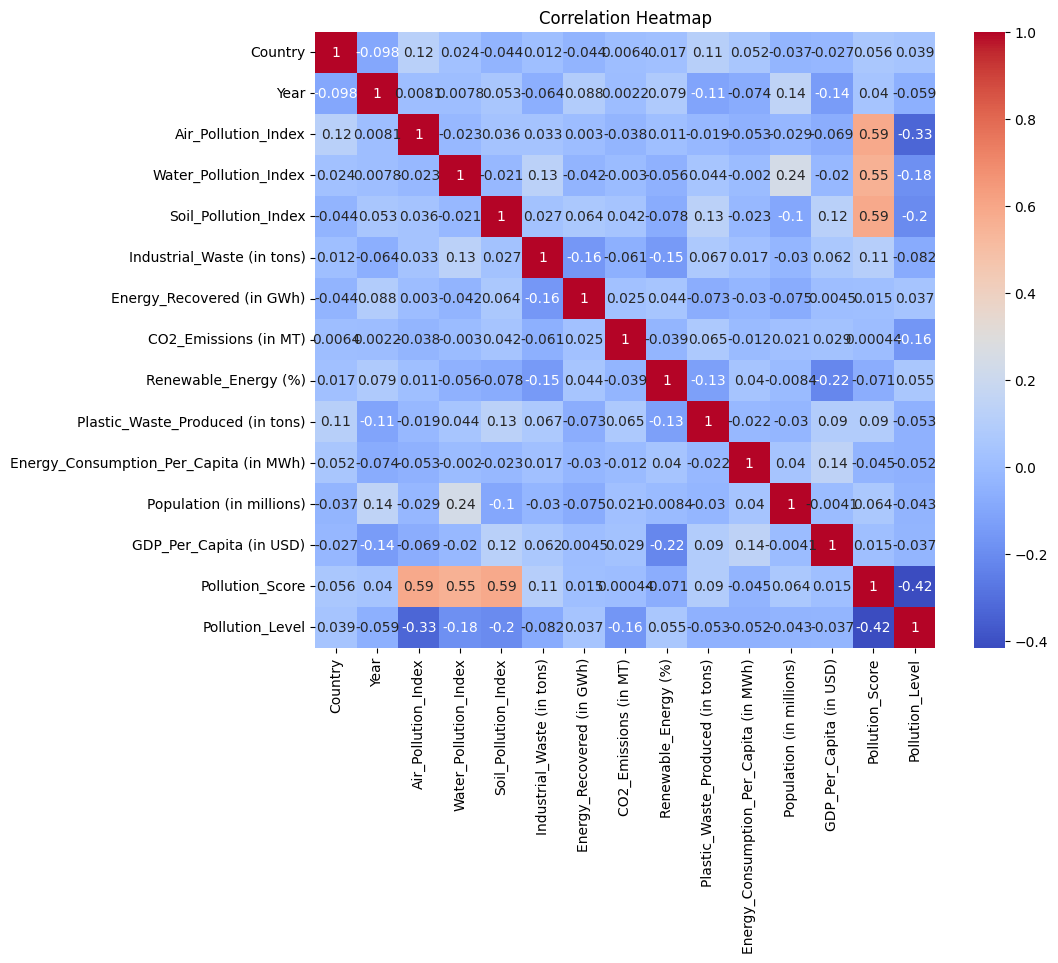

In [116]:
plt.figure(figsize=(10, 8))

plt.title("Correlation Heatmap")

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap = "coolwarm")

plt.show()

**2. Model Implementation**

Use Logistic Regression to classify pollution severity based on features like Air_Pollution_Index and CO2_Emissions.

In [127]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df[[
    "Air_Pollution_Index",
    "Industrial_Waste (in tons)",
    "CO2_Emissions (in MT)",
    "Renewable_Energy (%)"
]]

X_scaled = scaler.fit_transform(X)

Y = df["Pollution_Level"]

TRAIN-TEST SPLIT :

In [128]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X_scaled,
    Y,
    test_size=0.2,
    random_state=42
)

APPLYING LOGISTIC REGRESSION :

In [129]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, Y_train)

LogisticRegression(max_iter=1000)

3. Evaluation Metrics

Evaluate using metrics like Accuracy, Precision, Recall, F1-score, and plot the Confusion Matrix.


In [131]:
y_pred = model.predict(X_test)

In [135]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report: \n")
print(" 0:High \n 1:Low \n 2:Medium")
print(classification_report(y_test, y_pred))

Accuracy: 0.425

Classification Report: 

 0:High 
 1:Low 
 2:Medium
              precision    recall  f1-score   support

           0       0.38      0.50      0.43        10
           1       0.41      0.69      0.51        13
           2       0.60      0.18      0.27        17

    accuracy                           0.42        40
   macro avg       0.46      0.46      0.41        40
weighted avg       0.48      0.42      0.39        40



### Logistic Regression Results

A Logistic Regression model was trained to classify countries into High, Medium, and Low Pollution categories.

Results:
- Accuracy: 42.5%

Observations:
- The model achieved an accuracy of 42.5%, which is slightly better than random guessing for a three-class problem.
- The model performed best for the Low Pollution category with a recall of 69%.
- The Medium Pollution category was the most difficult to classify, achieving a recall of only 18%.
- Overall performance was moderate, suggesting that additional features or more advanced classification techniques may improve results.

# **Phase 3: Reporting and Insights**

## **Model Comparison and Insights**

Two machine learning models were developed as part of this analysis.

### Linear Regression
The Linear Regression model was used to predict Energy Recovered (in GWh). The model achieved an R² score of -0.015, indicating poor predictive performance. This suggests that the selected features have weak linear relationships with energy recovery.

### Logistic Regression
The Logistic Regression model was used to classify countries into Low, Medium, and High Pollution categories. The model achieved an accuracy of 42.5%, which is better than random guessing for a three-class classification problem.

| Model               | Objective                | Metric   | Result |
| ------------------- | ------------------------ | -------- | ------ |
| Linear Regression   | Predict Energy Recovery  | R² Score | -0.015 |
| Logistic Regression | Classify Pollution Level | Accuracy | 42.5%  |


###**Key Insights**
- Air Pollution Index generally remained higher than Water and Soil Pollution Indices.
- Pollution levels fluctuated over time rather than showing a consistent trend.
- Correlation analysis revealed weak relationships between Energy Recovery and most environmental indicators.
- Logistic Regression performed better relative to its objective than Linear Regression.

### **Recommendations**
- Collect additional features related to waste processing and energy production.
- Apply advanced machine learning models for improved predictive performance.
- Explore further feature engineering techniques to capture non-linear relationships.